Final TLFs for the website. Some stuff copied over from `eda.ipynb`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
data = pd.read_csv("data/eda_data.csv")
data.shape

(1804, 190)

# Attempt 1: Static Intervention

In [12]:
# Remove individuals with null exposure but measured outcome 
# (because doesn't make sense why; did they do the specimen tests and just not answer the questionnaire? data contamination?)

visit_prefix = ['HORMUSER', 'SPBMDT', 'HPBMDT'] 
throw_away_index = []
for i in range(2, 11):
    visit_i_col = [prefix + str(i) for prefix in visit_prefix]
    visit_i = data[visit_i_col]
    visit_i_temp = visit_i[visit_i[visit_i_col[0]].isna()].notna()
    visit_i_unique_nulls = visit_i_temp[visit_i_temp[visit_i_col[1]] | visit_i_temp[visit_i_col[2]]]
    throw_away_index.append(visit_i_unique_nulls.index.tolist())
data_no_null_hormuser = data.iloc[data.index.difference(sorted(sum(throw_away_index, [])))]
data_no_null_hormuser.shape

(1799, 190)

In [13]:
# Number of individuals per exposure group per visit 

hormuser = ['HORMUSER' + str(i) for i in range(0, 11)]
test = pd.melt(data[hormuser]).reset_index().groupby(['value', 'variable']).count().reset_index()
test_counts = pd.pivot_table(test, values='index', index='value', columns='variable', aggfunc='sum')
test_counts.loc['Total'] = test_counts.sum()
test_counts['HORMUSER10'] = test_counts.pop('HORMUSER10')
test_counts.index.names = ['No. of women']
test_counts.columns.names = ['Visit']
test_counts.reset_index(inplace=True)
test_counts.loc[:, 'No. of women'] = [0, 1, 'Total']
test_counts = test_counts.set_index('No. of women').fillna(0).astype(int)
test_counts

Visit,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
No. of women,,,,,,,,,,,
0,1804,1682,1495,1389,1314,1258,1276,1366,1374,1397,1399
1,0,122,204,260,306,338,340,216,160,133,125
Total,1804,1804,1699,1649,1620,1596,1616,1582,1534,1530,1524


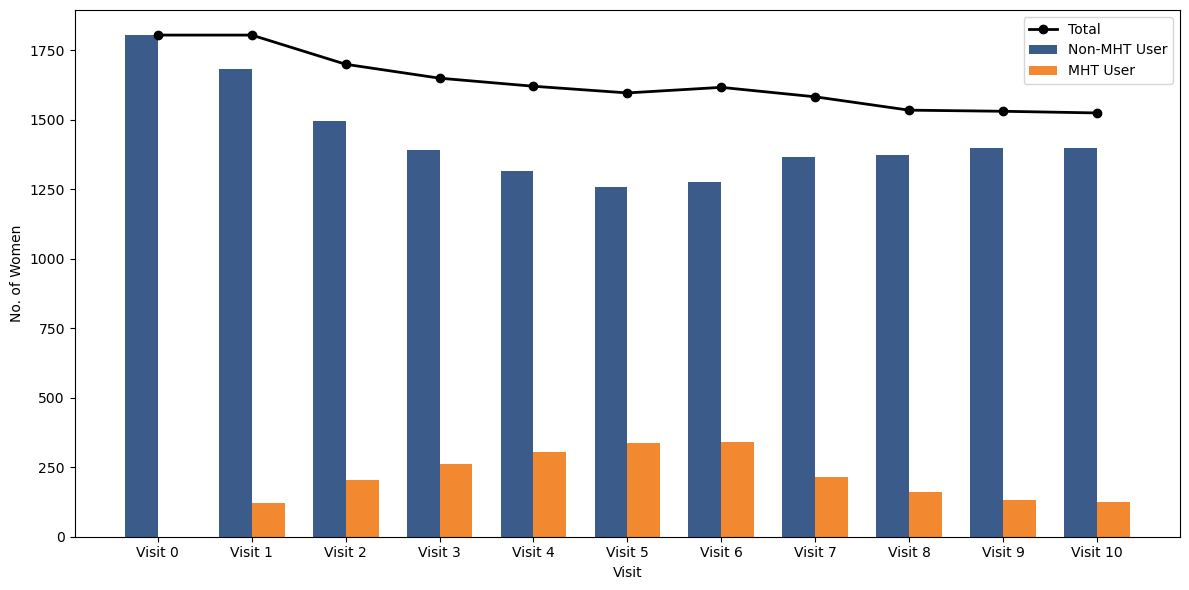

In [28]:
visits = ["Visit " + str(i) for i in range(0, 11)]
nonuser_count = test_counts.iloc[0].values
user_count = test_counts.iloc[1].values
total_count = test_counts.iloc[2].values

x = np.arange(len(visits))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
bars_nonuser = ax.bar(x - width/2, nonuser_count, width, label = "Non-MHT User", color = "#3b5b8a")
bars_user = ax.bar(x + width/2, user_count, width, label = "MHT User", color = "#f28830")
ax.plot(x, total_count, color = "black", marker = "o", linewidth = 2, label = "Total")

ax.set_xlabel("Visit")
ax.set_ylabel("No. of Women")
ax.set_xticks(x)
ax.set_xticklabels(visits)
ax.legend()

plt.tight_layout()
plt.savefig("plots/no_of_women_per_group_per_visit.png")
plt.show()

In [53]:
# Number of women that started MHTs at each visit
data_hormuser = data_no_null_hormuser[hormuser]
data_hormuser_bool = data_hormuser == 1
v = data_hormuser_bool.cumsum(axis=1)
num_women_start_each_visit = v.eq(1).dot(v.columns+',').str.split(',').str[0].value_counts()
num_women_start_each_visit = num_women_start_each_visit.rename(index = {"": "HORMUSER0"})
num_women_start_each_visit.sort_index(key = lambda x: x.map({val: i for i, val in enumerate(v.columns.tolist())}), inplace = True)
num_women_start_each_visit

HORMUSER0     1167
HORMUSER1      121
HORMUSER2      116
HORMUSER3      108
HORMUSER4       86
HORMUSER5       74
HORMUSER6       51
HORMUSER7       22
HORMUSER8       26
HORMUSER9       11
HORMUSER10      17
Name: count, dtype: int64

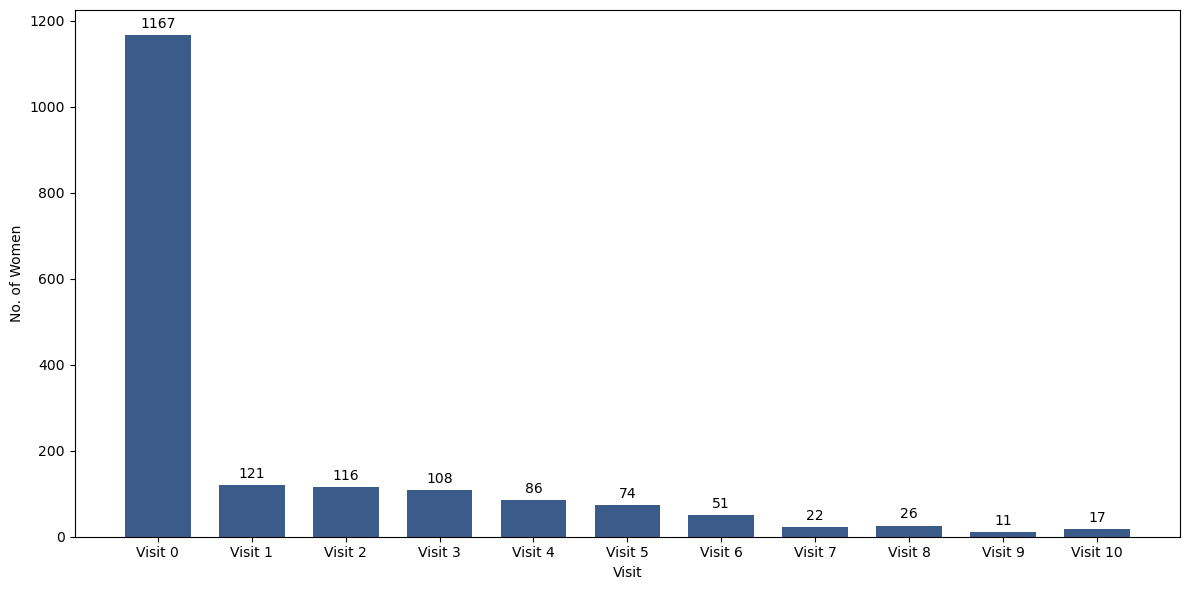

In [51]:
fig, ax = plt.subplots(figsize=(12,6))
bars_startMHTs = ax.bar(x, num_women_start_each_visit.values, width * 2, color = "#3b5b8a")

ax.set_xlabel("Visit")
ax.set_ylabel("No. of Women")
ax.set_xticks(x)
ax.set_xticklabels(visits)
ax.bar_label(bars_startMHTs, padding=3)

plt.tight_layout()
plt.savefig("plots/no_of_women_start_MHT_per_visit.png")
plt.show()

In [52]:
# Number of visits where HORMUSER = 1
num_women_stay_on_mht = v['HORMUSER10'].value_counts()
num_women_stay_on_mht

HORMUSER10
0     1167
1      174
2      112
3       85
4       69
5       58
6       55
8       26
7       24
9       17
10      12
Name: count, dtype: int64

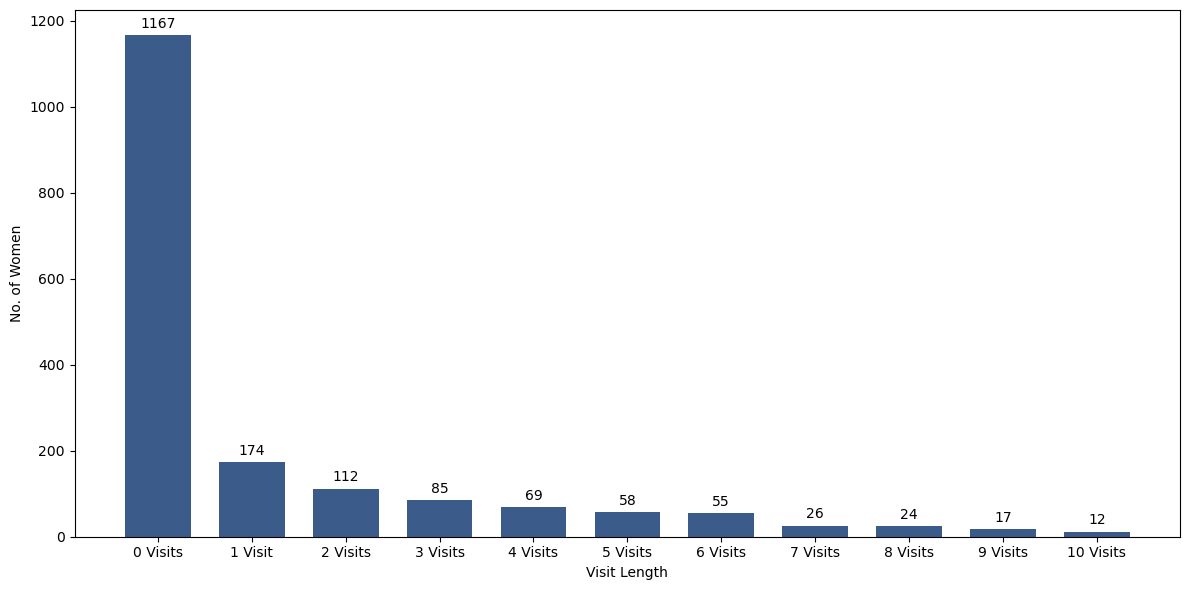

In [58]:
visit_lengths = [str(i) + " Visits" if i != 1 else "1 Visit" for i in range(0, 11)]
fig, ax = plt.subplots(figsize=(12,6))
bars_stayMHTs = ax.bar(x, num_women_stay_on_mht.values, width * 2, color = "#3b5b8a")

ax.set_xlabel("Visit Length")
ax.set_ylabel("No. of Women")
ax.set_xticks(x)
ax.set_xticklabels(visit_lengths)
ax.bar_label(bars_stayMHTs, padding=3)

plt.tight_layout()
plt.savefig("plots/no_of_women_stay_on_MHT_per_visit_length.png")
plt.show()

# Attempt 4: Effect Heteroegenity 

In [89]:
# average age at start of study
data_no_null_hormuser["AGE"].describe()

count    1799.000000
mean       45.878266
std         2.688535
min        42.000000
25%        44.000000
50%        46.000000
75%        48.000000
max        53.000000
Name: AGE, dtype: float64

In [104]:
# average age at start of MHTs
add_to_age = v.eq(1).dot(v.columns+',').str.split(',').str[0].str.extract("(\d+)").fillna(0).astype(int)
data_age_at_start_MHT = data_no_null_hormuser.copy()
data_age_at_start_MHT["add_to_age"] = add_to_age
women_start_MHTs = data_age_at_start_MHT[data_age_at_start_MHT["add_to_age"] != 0].copy()
women_start_MHTs["AGE_AT_START_MHT"] = women_start_MHTs["AGE"] + women_start_MHTs["add_to_age"]
women_start_MHTs["AGE_AT_START_MHT"].describe()

count    632.000000
mean      50.137658
std        2.979333
min       43.000000
25%       48.000000
50%       50.000000
75%       52.000000
max       60.000000
Name: AGE_AT_START_MHT, dtype: float64

In [67]:
# age of women when they start MHT and wrt to menopausal status
status_cols = ["STATUS" + str(i) for i in range(0, 11)]
data_no_null_hormuser[["AGE"] + hormuser + status_cols]

,AGE,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,...,STATUS1,STATUS2,STATUS3,STATUS4,STATUS5,STATUS6,STATUS7,STATUS8,STATUS9,STATUS10
0,52,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
1,51,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,45,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,51,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,46,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,46,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
1800,43,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,3.0,3.0
1801,44,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,48,0,1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,6.0,3.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0


In [74]:
data_no_null_hormuser["STATUS1"].value_counts()

STATUS1
3.0    1080
4.0     459
6.0     152
2.0      71
1.0      20
0.0       7
7.0       6
Name: count, dtype: int64